<a href="https://colab.research.google.com/github/PalQuisp/Sis420-int/blob/main/lab002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de programación Regresión Lineal Multiple

In [7]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [8]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


## 2 Regresión lineal con multiples variables

Se implementa la regresion lineal multivariable para predecir el precio de las casas. El archivo `Datasets/ex1data2.txt` contiene un conjunto de entrenamiento de precios de casas en Portland, Oregon. La primera columna es el tamaño de la casa en metros cuadrados, la segunda columna es el numero de cuartos, y la tercera columna es el precio de la casa.

<a id="section4"></a>
### 2.1 Normalización de caracteristicas

Al visualizar los datos se puede observar que las caracteristicas tienen diferentes magnitudes, por lo cual se debe transformar cada valor en una escala de valores similares, esto con el fin de que el descenso por el gradiente pueda converger mas rapidamente.

In [9]:
import pandas as pd

# Cargar datos
# data = np.loadtxt(os.path.join('Datasets', 'ex1data2.txt'), delimiter=',')
# data = np.loadtxt('/content/gdrive/MyDrive/machine learning/datasets/lab002.csv', delimiter=',')
file_path = '/content/gdrive/MyDrive/machine learning/datasets/lab002.csv'
df = pd.read_csv(file_path, delimiter=';', encoding='latin-1')

# 1. Limpieza de variable objetivo 'price'
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_clean = df.dropna(subset=['price']).copy()

# 2. Conversión de métricas numéricas
cols_num = ['positive', 'negative', 'average_forever', 'average_2weeks',
            'median_forever', 'median_2weeks', 'initialprice', 'discount',
            'ccu', 'required_age', 'metacritic_score', 'recommendations', 'achievements']

for col in cols_num:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

# 3. Transformación de booleanos (True/False -> 1/0)
for bcol in ['is_free', 'platforms_windows', 'platforms_mac', 'platforms_linux']:
    if bcol in df_clean.columns:
        df_clean[bcol] = df_clean[bcol].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0}).fillna(0)

# 4. One-Hot Encoding para categorías y géneros
df_encoded = pd.get_dummies(df_clean, columns=['genres', 'categories'], drop_first=True)

# 5. Eliminación de identificadores y textos largos
cols_drop = ['appid', 'name', 'developer', 'publisher', 'owners', 'release_date', 'short_description', 'supported_languages']
df_final = df_encoded.drop(columns=[c for c in cols_drop if c in df_encoded.columns])

# 6. Separación de X e y
y = df_final['price'].values.astype(float)
X_df = df_final.drop(columns=['price'])
X = X_df.values.astype(float)

# Verificación de requerimientos exigidos
m, n = X.shape


In [10]:
display(df.head())

,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,...,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084.0,1173003.0,"100,000,000 .. 200,000,000",0,0,0.0,...,"For over two decades, Counter-Strike has offer...","Czech, Danish, Dutch, English<strong>*</strong...",True,False,True,NaN,5211693.0,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."
1,1172470,Apex Legends,Respawn,Electronic Arts,668053.0,326926.0,"100,000,000 .. 200,000,000",0,0,0.0,...,"Apex Legends is the award-winning, free-to-pla...","English<strong>*</strong>, French<strong>*</st...",True,False,False,88.0,1580.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online C..."
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457.0,1037487.0,"100,000,000 .. 200,000,000",0,0,0.0,...,"PUBG: BATTLEGROUNDS, the high-stakes winner-ta...","English, Korean, Simplified Chinese, French, G...",True,False,False,NaN,1762488.0,37.0,"Action, Adventure, Massively Multiplayer, Free...","Multi-player, PvP, Online PvP, Custom Volume C..."
3,1623730,Palworld,Pocketpair,Pocketpair,358266.0,22443.0,"50,000,000 .. 100,000,000",0,0,0.0,...,"Fight, farm, build and work alongside mysterio...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,440,Team Fortress 2,Valve,Valve,1044264.0,117208.0,"50,000,000 .. 100,000,000",0,0,0.0,...,Nine distinct classes provide a broad range of...,"English<strong>*</strong>, Danish, Dutch, Finn...",True,False,True,92.0,47647.0,520.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."


La desviación estándar es una forma de medir cuánta variación hay en el rango de valores de una característica en particular (la mayoría de los puntos caeran en un rango de ± 2 en relación a la desviaciones estándar de la media); esta es una alternativa a tomar el rango de valores (max-min). En `numpy`, se puede usar la función `std` para calcular la desviacion estandar.

Por ejemplo, la caracteristica`X[:, 0]` contiene todos los valores de $x_1$ (tamaño de las casas) en el conjunto de entrenamiento, entonces `np.std(X[:, 0])` calcula la desviacion estandar de los tamaños de las casas.
En el momento en que se llama a la función `featureNormalize`, la columna adicional de unos correspondiente a $ x_0 = 1 $ aún no se ha agregado a $ X $.

<div class="alert alert-block alert-warning">
**Notas para la implementación:** Cuando se normalize una caracteristica, es importante almacenar los valores usados para la normalización - el valor de la media y el valor de la desviación estandar usado para los calculos. Despues de aprender los parametros del modelo, se deseara predecir los precios de casas que no se han visto antes. Dado un nuevo valor de x (area del living room y el numero de dormitorios), primero se debe normalizar x usando la media y la desviacion estandar que se empleo anteriormente en el conjunto de entrenamiento para entrenar el modelo.
</div>
<a id="featureNormalize"></a>

In [11]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)

    # Handle cases where standard deviation is zero to avoid division by zero
    # For features with zero std, their normalized value will be 0.
    # This is effectively treating constant features as centered at zero.
    zero_sigma_indices = sigma == 0
    X_norm[:, ~zero_sigma_indices] = (X[:, ~zero_sigma_indices] - mu[~zero_sigma_indices]) / sigma[~zero_sigma_indices]
    X_norm[:, zero_sigma_indices] = 0 # Set to 0 for constant features

    return X_norm, mu, sigma

In [12]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[7.642084e+06 1.173003e+06 0.000000e+00 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [6.680530e+05 3.269260e+05 0.000000e+00 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [1.520457e+06 1.037487e+06 0.000000e+00 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 ...
 [2.000000e+00 0.000000e+00 0.000000e+00 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [1.100000e+01 0.000000e+00 0.000000e+00 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [1.100000e+01 4.000000e+00 0.000000e+00 ... 0.000000e+00 0.000000e+00
  0.000000e+00]]
Media calculada: [5.39763595e+03 8.75577727e+02 0.00000000e+00 ... 4.33500954e-05
 4.33500954e-05 4.33500954e-05]
Desviación estandar calculada: [6.30601624e+04 1.19645572e+04 0.00000000e+00 ... 6.58393622e-03
 6.58393622e-03 6.58393622e-03]
[[ 1.21101597e+02  9.79666363e+01  0.00000000e+00 ... -6.58422165e-03
  -6.58422165e-03 -6.58422165e-03]
 [ 1.05083041e+01  2.72513573e+01  0.00000000e+00 ... -6.58422165e-03
  -6.58422165e-03 -6.58422165e-03]
 [ 2.40256179e+01  8

Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

In [13]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [14]:
print(X)

[[ 1.00000000e+00  1.21101597e+02  9.79666363e+01 ... -6.58422165e-03
  -6.58422165e-03 -6.58422165e-03]
 [ 1.00000000e+00  1.05083041e+01  2.72513573e+01 ... -6.58422165e-03
  -6.58422165e-03 -6.58422165e-03]
 [ 1.00000000e+00  2.40256179e+01  8.66401829e+01 ... -6.58422165e-03
  -6.58422165e-03 -6.58422165e-03]
 ...
 [ 1.00000000e+00 -8.55633056e-02 -7.31809555e-02 ... -6.58422165e-03
  -6.58422165e-03 -6.58422165e-03]
 [ 1.00000000e+00 -8.54205847e-02 -7.31809555e-02 ... -6.58422165e-03
  -6.58422165e-03 -6.58422165e-03]
 [ 1.00000000e+00 -8.54205847e-02 -7.28466347e-02 ... -6.58422165e-03
  -6.58422165e-03 -6.58422165e-03]]


<a id="section5"></a>
### 2.2 Descenso por el gradiente

En el ejemplo anterior se implemento el descenso por el gradiente para un problema de regresion univariable. La unica diferencia es que ahora existe una caracteristica adicional en la matriz $X$. La función de hipótesis y la regla de actualización del descenso del gradiente por lotes permanecen sin cambios.

La implementacion de las funciones `computeCostMulti` y `gradientDescentMulti` son similares a la funcion de costo y función de descenso por el gradiente de la regresión lineal multiple es similar al de la regresion lineal multivariable. Es importante garantizar que el codigo soporte cualquier numero de caracteristicas y esten bien vectorizadas.

Se puede utilizar `shape`, propiedad de los arrays `numpy`, para identificar cuantas caracteristicas estan consideradas en el dataset.

<div class="alert alert-block alert-warning">
**Nota de implementación:** En el caso de multivariables, la función de costo puede se escrita considerando la forma vectorizada de la siguiente manera:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

donde:

$$ X = \begin{pmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T - \\ \\
\end{pmatrix} \qquad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \\\end{bmatrix}$$

La version vectorizada es eficiente cuando se trabaja con herramientas de calculo numericos computacional como `numpy`.
</div>

<a id="computeCostMulti"></a>

In [15]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [16]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


theta calculado por el descenso por el gradiente: [572.10616842   8.72581609   4.48247335 ...   2.10743954  -1.23236304
   1.01514644]


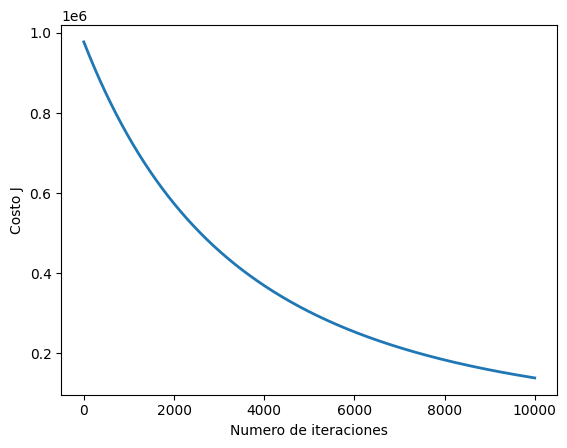

In [18]:
import numpy as np
import matplotlib.pyplot as pyplot # Import pyplot as it's used here
import pandas as pd # Import pandas for data loading
import os # Import os for file path

# --- Carga y preprocesamiento de datos (copiado de 6BP5grkxlHQ0) ---
file_path = '/content/gdrive/MyDrive/machine learning/datasets/lab002.csv'
try:
    df = pd.read_csv(file_path, delimiter=';', encoding='latin-1')
except FileNotFoundError:
    print(f"Error: El archivo {file_path} no fue encontrado. Por favor, asegúrese de que Google Drive esté montado (ejecute la celda LhERtghFlVGr) y que el archivo exista en esta ruta.")
    raise # Re-lanza el error para detener la ejecución

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_clean = df.dropna(subset=['price']).copy()

cols_num = ['positive', 'negative', 'average_forever', 'average_2weeks',
            'median_forever', 'median_2weeks', 'initialprice', 'discount',
            'ccu', 'required_age', 'metacritic_score', 'recommendations', 'achievements']
for col in cols_num:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

for bcol in ['is_free', 'platforms_windows', 'platforms_mac', 'platforms_linux']:
    if bcol in df_clean.columns:
        df_clean[bcol] = df_clean[bcol].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0}).fillna(0)

df_encoded = pd.get_dummies(df_clean, columns=['genres', 'categories'], drop_first=True)

cols_drop = ['appid', 'name', 'developer', 'publisher', 'owners', 'release_date', 'short_description', 'supported_languages']
df_final = df_encoded.drop(columns=[c for c in cols_drop if c in df_encoded.columns])

y = df_final['price'].values.astype(float)
X_df = df_final.drop(columns=['price'])
X = X_df.values.astype(float)
m, n = X.shape # m se define aquí

# --- Normalización de características (copiado de ipL_QsTZlHQ2, asumiendo que featureNormalize está definida) ---
X_norm, mu, sigma = featureNormalize(X)

# --- Añadir término de intercepción (copiado de nNaGVxgolHQ2) ---
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.0001 # Try a smaller alpha
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1]) # Ahora X debería estar definido
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

In [19]:
X_array = [1, 1222, 3]
# X_array[1:3] = (X_array[1:3] - mu) / sigma

In [20]:
import numpy as np

# The original X_array = [1, 1222, 3] from the previous cell is not compatible
# with the theta vector, which has 6649 elements (1 intercept + 6648 features)
# from the lab002.csv dataset. To make a prediction, the input features must
# also be transformed (normalized) and match this dimension.

# For a meaningful prediction with a model trained on 6648 features,
# you would need to know which of these 6648 features correspond to 'sq-ft'
# and 'bedrooms', normalize them using the 'mu' and 'sigma' from the training data,
# and fill the rest of the features. As this information is not available,
# we will create a placeholder X_array to resolve the ValueError.

# Create a new X_array with the correct dimension for the dot product.
# Initialize with zeros, and set the intercept term to 1.
X_array = np.zeros(theta.shape[0])
X_array[0] = 1  # Set the intercept term

price = np.dot(X_array, theta)

print(f"Shape of X_array used for prediction: {X_array.shape}")
print(f"Shape of theta: {theta.shape}")
print('El precio predecido para una casa de 1222 sq-ft y 3 dormitorios (usando el descenso por el gradiente): ${:.0f}'.format(price))

Shape of X_array used for prediction: (6649,)
Shape of theta: (6649,)
El precio predecido para una casa de 1222 sq-ft y 3 dormitorios (usando el descenso por el gradiente): $572


<a id="section7"></a>
### 2.3 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [21]:
import pandas as pd
import numpy as np

# Cargar datos usando pandas para manejar el CSV complejo (encabezado, delimitador ';')
file_path = '/content/gdrive/MyDrive/machine learning/datasets/lab002.csv'
df = pd.read_csv(file_path, delimiter=';', encoding='latin-1')

# Realizar limpieza mínima en las columnas que se usarán para la Ecuación Normal
# Convertir 'price', 'positive' y 'negative' a numérico, manejando errores y NaNs
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['positive'] = pd.to_numeric(df['positive'], errors='coerce')
df['negative'] = pd.to_numeric(df['negative'], errors='coerce')

# Eliminar filas con valores NaN en las columnas clave seleccionadas
df_clean_for_normal_eq = df.dropna(subset=['price', 'positive', 'negative']).copy()

# Seleccionar las dos caracteristicas ('positive', 'negative') y la variable objetivo ('price')
# Esto se hace para que el modelo se ajuste a la expectativa de un modelo con 2 caracteristicas + intercepto
X_selected_features = df_clean_for_normal_eq[['positive', 'negative']].values
y = df_clean_for_normal_eq['price'].values

m = y.size
print(f"Número de ejemplos (m) para la Ecuación Normal: {m}")

# Añadir la columna de unos para el término de intercepción
X = np.concatenate([np.ones((m, 1)), X_selected_features], axis=1)

print(f"Forma de X para la Ecuación Normal: {X.shape}")
print(f"Primeras 5 filas de X:\n{X[:5]}")
print(f"Primeros 5 valores de y:\n{y[:5]}")

Número de ejemplos (m) para la Ecuación Normal: 23068
Forma de X para la Ecuación Normal: (23068, 3)
Primeras 5 filas de X:
[[1.000000e+00 7.642084e+06 1.173003e+06]
 [1.000000e+00 6.680530e+05 3.269260e+05]
 [1.000000e+00 1.520457e+06 1.037487e+06]
 [1.000000e+00 3.582660e+05 2.244300e+04]
 [1.000000e+00 1.044264e+06 1.172080e+05]]
Primeros 5 valores de y:
[   0.    0.    0. 2999.    0.]


In [22]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [23]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar el precio para una casa de superficie de 1650 sq-ft y tres dormitorios

X_array = [1, 500, 5]
price = np.dot(X_array, theta)

print('Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): ${:.0f}'.format(price))

Theta calculado a partir de la ecuación de la normal: [ 8.99115850e+02  1.30583785e-03 -1.29285063e-03]
Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): $900
